# 第12章：横截面排序与股票组合

**问题：同一个调仓日，小市值股票与大市值股票的后续表现有什么不同？**

本章先提出规模假设，再构建五组组合，用真实历史数据检查结果，不预设小市值一定胜出。
唯一输入是第11章的共享 `data/stock_daily.parquet`；使用从2021年开始的全部可用历史。

学习路线：读取共享数据 → 确定信号与持有时间 → 市值分组 → 组合估值 → 比较风险收益 → 检查成本与微盘影响。

本章是理想化组合研究，不是可直接实盘执行的交易系统。缺失估值、退市回收、停牌退出和成交冲击的边界见第8节。

## 1. 环境、路径与参数

使用课程根目录 `.venv`，无需重新安装依赖。Windows与macOS使用相同Notebook代码。
从课程根目录、本章目录或Notebook目录启动均可。只读共享行情，不复制或重建Parquet。

`Dsmvtl2`是总股数乘A股价格的“总市值2”（千元），不是A/B/H分别按各自价格加总的市值。
主样本仅在**信号日**筛选正常交易状态；持有后变成ST或停牌的股票不能从历史持仓中直接删除。

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet").is_file())
CHAPTER = ROOT / "Chapter12 - 横截面排序与股票组合"
SOURCE = ROOT / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet"
TABLES = CHAPTER / "outputs/tables"
FIGURES = CHAPTER / "latex/figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SIZE = "Dsmvtl2"
N_GROUPS = 5
COST_PER_SIDE = 0.001  # 每买入或卖出1元，假设成本0.001元：10bp情景
GROUPS = [f"G{i}" for i in range(1, N_GROUPS + 1)]
BOARD = {1: "沪主板", 4: "深主板", 16: "创业板", 32: "科创板", 64: "北交所"}
fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ["Microsoft YaHei", "PingFang SC", "SimHei"] if f in fonts), "DejaVu Sans")
plt.rcParams.update({"font.family": font, "axes.unicode_minus": False,
                     "figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_columns", 12)
print("共享输入：", SOURCE.relative_to(ROOT))
print("Python / pandas：", platform.python_version(), pd.__version__)

共享输入： Chapter11 - 股票日频收益率分析\data\stock_daily.parquet
Python / pandas： 3.11.15 2.3.3


## 2. 读取最长历史与核对数据

只选本章使用的列，但不按年份截断。行情日期是交易所本地日期。
先检查代码×日期唯一性；重复键应调查来源，不能用随手去重掩盖问题。
真实交易日期从A股非填充、有成交记录中取得，节假日填充不能进入交易日历。

In [2]:
columns = ["Stkcd", "Trddt", "Markettype", "Trdsta", "Filling", "Dnshrtrd",
           "Clsprc", "Dsmvtl2", "Dsmvosd", "Adjprcwd", "Dretwd", "LimitStatus"]
raw = pd.read_parquet(SOURCE, columns=columns)
raw["Stkcd"] = raw["Stkcd"].astype("string").str.zfill(6)
source_rows = pq.ParquetFile(SOURCE).metadata.num_rows
assert len(raw) == source_rows
assert raw[["Stkcd", "Trddt"]].notna().all().all()
assert not raw.duplicated(["Stkcd", "Trddt"]).any()
data = raw.loc[raw.Markettype.isin(BOARD)].copy()
source_start, source_end = raw.Trddt.min(), raw.Trddt.max()
calendar = pd.DatetimeIndex(sorted(data.loc[data.Filling.eq(0) & data.Dnshrtrd.gt(0), "Trddt"].unique()))
profile = data.groupby(data.Trddt.dt.year).agg(
    rows=("Stkcd", "size"), stocks=("Stkcd", "nunique"), recorded_dates=("Trddt", "nunique"))
profile["trading_dates"] = pd.Series(calendar.year).value_counts().sort_index()
print(f"全包{len(raw):,}行；A股{len(data):,}行；{source_start.date()}至{source_end.date()}")
display(profile)
display(data[[SIZE, "Adjprcwd", "Dretwd"]].isna().sum().rename("缺失记录数").to_frame())
del raw

全包6,888,585行；A股6,778,694行；2021-08-16至2026-08-13


,rows,stocks,recorded_dates,trading_dates
Trddt,,,,
2021,458867,4688,100,93
2022,1260986,5113,260,242
2023,1354201,5380,260,242
2024,1403825,5435,262,242
2025,1414730,5500,261,243
2026,886085,5564,161,148


,缺失记录数
Dsmvtl2,0
Adjprcwd,389
Dretwd,0


### 2.1 建立估值矩阵，保留持有期间的缺失

使用非填充记录中的含红利可比价格 `Adjprcwd`。其比值包含现金红利再投资，可与第11章 `Dretwd` 衔接。

无有效观测时沿用过去估值：`ffill()`只从过去向未来传播，**不使用 `bfill()`**。这意味着暂时记为零估值变动，恢复观测后一次性确认变化；不是断言停牌股票没有经济损失。记录终止后也会沿用旧估值，不能据此认为退市已处理。
`observed`保存原始可用性，用于统计持仓估值缺口。

In [3]:
actual = data.loc[data.Filling.eq(0)].copy()
actual["Adjprcwd"] = actual.Adjprcwd.where(np.isfinite(actual.Adjprcwd) & actual.Adjprcwd.gt(0))
# pivot将长表转为“日期×股票”矩阵；reindex统一市场交易日，缺少记录的位置保留NaN。
observed = actual.pivot(index="Trddt", columns="Stkcd", values="Adjprcwd").reindex(calendar)
# observed保留实际观测，prices用于持仓估值：只沿用过去价格，恢复观测后体现累计变化。
prices = observed.ffill()
volume = actual.pivot(index="Trddt", columns="Stkcd", values="Dnshrtrd").reindex(index=calendar, columns=prices.columns)
limits = actual.pivot(index="Trddt", columns="Stkcd", values="LimitStatus").reindex(index=calendar, columns=prices.columns)
# 这里只检查当日有价格且有成交；并未保证涨跌停股票可以按收盘价成交。
tradable = observed.notna() & volume.gt(0)

# 相邻真实观测的价格回报，应与数据库回报口径吻合；只比较相邻市场交易日。
reported = actual.pivot(index="Trddt", columns="Stkcd", values="Dretwd").reindex(index=calendar, columns=prices.columns)
adjacent = observed.notna() & observed.shift(1).notna()
return_gap = (observed / observed.shift(1) - 1 - reported).where(adjacent).abs()
max_return_gap = float(return_gap.max().max())
print("相邻可比价格回报与Dretwd最大绝对差：", max_return_gap)
assert max_return_gap < 1e-5
del reported, return_gap

相邻可比价格回报与Dretwd最大绝对差： 5.311710643690626e-06


## 3. 先画时间线，再写回测

设月末最后交易日为 $e$，其前一交易日为 $s$：

1. $s$收盘后：按当日市值与可见状态筛选、排序。
2. $e$收盘：按预定分组建仓；当天收益不归新组合。
3. $e$之后至下个月末：持有并估值，月内权重自然漂移。

为了不把2026年8月13日误认为8月月末，最后一个数据月份不生成新调仓；已有组合继续估值至文件末日。
第一期不需要收益回看窗口，所以2021年8月底即可建仓。

In [4]:
# 将市场交易日按自然月分组，避免把周末、节假日当作调仓日。
month_dates = pd.Series(calendar, index=calendar).groupby(calendar.to_period("M"))
schedule_rows = []
for month, dates in month_dates:
    if month == calendar[-1].to_period("M"):
        continue  # 数据结束月份没有后续月份来确认完整月末
    # 倒数第二日收盘形成信号，最后一日收盘建仓；新组合不赚取建仓日当天的收益。
    signal, execution = dates.iloc[-2], dates.iloc[-1]
    schedule_rows.append({"signal_date": signal, "execution_date": execution})
schedule = pd.DataFrame(schedule_rows)
# shift(-1)把下一次建仓日对齐到本期，作为本期持有终点。
# 这里使用未来日期来划分收益区间，不使用未来市值或收益决定选股；末期持有至数据末日。
schedule["holding_end"] = schedule.execution_date.shift(-1).fillna(calendar[-1])
assert (schedule.signal_date < schedule.execution_date).all()
assert (schedule.execution_date < schedule.holding_end).all()
display(pd.concat([schedule.head(3), schedule.tail(3)]))

,signal_date,execution_date,holding_end
0,2021-08-30,2021-08-31,2021-09-30
1,2021-09-29,2021-09-30,2021-10-29
2,2021-10-28,2021-10-29,2021-11-30
57,2026-05-28,2026-05-29,2026-06-30
58,2026-06-29,2026-06-30,2026-07-31
59,2026-07-30,2026-07-31,2026-08-13


### 3.1 只依据当时信息选股

主样本：A股、信号日正常交易状态（`Trdsta == 1`）、非填充、有成交、正市值、有效价格。
不要求股票在样本结束时仍存在，不要求其未来每一天都有数据。行业、正式上市退市日期及代码变更映射不在本包内；因此不声称已经排除所有幸存者偏差。

等数量分组先按市值、代码排序，用顺序位置均分五组。G1最小，G5最大；同市值的边界股票可能按代码分开。

In [5]:
# 只取各信号日的股票截面，后续筛选不查看股票未来是否存续或是否有收益记录。
signal_rows = data.loc[data.Trddt.isin(schedule.signal_date)].copy()
# 各布尔条件逐行取交集：正常交易、有成交，且价格和规模有效。
signal_rows["eligible"] = (
    signal_rows.Filling.eq(0) & signal_rows.Trdsta.eq(1)
    & signal_rows.Dnshrtrd.gt(0) & signal_rows.Clsprc.gt(0)
    & np.isfinite(signal_rows[SIZE]) & signal_rows[SIZE].gt(0)
    & np.isfinite(signal_rows.Adjprcwd) & signal_rows.Adjprcwd.gt(0))
# 布尔值求和等于True的数量，用来对照每个信号日筛选前后的股票数。
sample_flow = signal_rows.groupby("Trddt").agg(
    a_share_rows=("Stkcd", "size"), eligible=("eligible", "sum"))

# 输入一个信号日，返回该日可选股票及其组别；exclude_bottom用于微盘敏感性实验。
def sort_stocks(signal_date, exclude_bottom=0.0):
    cross = signal_rows.loc[signal_rows.Trddt.eq(signal_date) & signal_rows.eligible].copy()
    # 按市值从小到大排列；同市值按代码打破并列，并把行号重置为0至N-1。
    cross = cross.sort_values([SIZE, "Stkcd"]).reset_index(drop=True)
    if exclude_bottom:
        # 先去掉排序最前面的指定比例，再对剩余股票重新分组，不沿用原组别。
        cross = cross.iloc[int(len(cross) * exclude_bottom):].reset_index(drop=True)
    # 位置×组数//股票数得到从0开始的组号，再加1；五组股票数最多相差1只。
    # 例如10只股票分5组：位置0、1属于G1，位置8、9属于G5；G1对应最小市值。
    cross["group"] = "G" + (np.arange(len(cross)) * N_GROUPS // len(cross) + 1).astype(str)
    return cross

example = sort_stocks(schedule.signal_date.iloc[0])
# 检查首期各组数量与市值区间，确认“从小到大”的分组方向正确。
example_summary = example.groupby("group").agg(
    stocks=("Stkcd", "size"), min_size=(SIZE, "min"), median_size=(SIZE, "median"), max_size=(SIZE, "max"))
display(example_summary.assign(**{c: example_summary[c] / 1e5 for c in ["min_size", "median_size", "max_size"]}))
print("市值列已换算为亿元；千元转亿元除以100000。")

,stocks,min_size,median_size,max_size
group,,,,
G1,864,3.880000,22.805593,30.524400
G2,864,30.540000,37.980703,47.458504
G3,864,47.486406,61.207382,81.906667
G4,864,81.975513,120.255943,195.682073
G5,863,195.704488,377.143462,19923.297108


市值列已换算为亿元；千元转亿元除以100000。


## 4. 等权、市值加权与持有期收益

建仓权重：等权 $w_i=1/N$；市值加权 $w_i=ME_{i,s}/\sum_j ME_{j,s}$，使用信号日市值。

设含红利可比价格为 $P^*_{i,t}$，以执行日价格为基准：

$$V_{g,t}=c_g+\sum_i w_{i,g}\frac{P^*_{i,t}}{P^*_{i,e}},\qquad r_{g,t}=V_{g,t}/V_{g,t-1}-1.$$

若执行日某股票无交易或无有效价格，预定金额留为零利息现金 $c_g$，不把它分配给其他股票。
月内不再等权。例：两只股票各投0.5，第一天一只涨10%、另一只不变，第二天仍按0.5/0.5计算就改变了策略。

In [6]:
toy_prices = pd.DataFrame({"A": [100, 110, 121], "B": [100, 100, 100]})
# 各列先除以建仓价格得到资产价值倍数，再乘初始投入；按行求和得到组合净值。
toy_value = (toy_prices / toy_prices.iloc[0]).mul([0.5, 0.5]).sum(axis=1)
# 逐日对两只股票收益取平均，隐含每天把权重调回50%/50%，与买入持有不同。
toy_daily_rebalanced = toy_prices.pct_change().mean(axis=1).dropna().add(1).prod()
assert np.isclose(toy_value.iloc[-1], 1.105)
assert np.isclose(toy_daily_rebalanced, 1.1025)
print(f"买入持有终值：{toy_value.iloc[-1]:.4f}；每日恢复等权终值：{toy_daily_rebalanced:.4f}")

买入持有终值：1.1050；每日恢复等权终值：1.1025


### 4.1 构造目标权重

`ALL`是同一个候选股票池的自建基准。用同样的调仓日、成交假设与加权方式，避免比较口径混乱。
这里暂不拦截涨跌停成交，只记录其目标权重；日频数据不能确认排队成交。

In [7]:
# 输入当期分组、建仓日和加权方式；返回实际初始权重、现金权重及成交检查前的目标权重。
def target_weights(cross, execution, weighting):
    # 权重矩阵的行是股票、列是组合；未入选股票的权重为0，便于跨月按代码对齐。
    weights = pd.DataFrame(0.0, index=prices.columns, columns=GROUPS + ["ALL"])
    for name in weights.columns:
        # G1至G5各取本组股票；ALL取同一候选池全部股票，构建口径一致的基准。
        part = cross if name == "ALL" else cross.loc[cross.group.eq(name)]
        # EW先给每只股票相同基数1；VW使用信号日市值作为基数，索引都设为股票代码。
        base = pd.Series(1.0, index=part.Stkcd) if weighting == "EW" else part.set_index("Stkcd")[SIZE]
        # 除以基数合计后，得到总和为1的组内权重；按股票标签写入对应组合列。
        weights.loc[base.index, name] = base / base.sum()
    # 保留原计划，用于检查涨跌停目标权重；copy避免后续修改同时影响这份记录。
    proposed = weights.copy()
    # 建仓日缺少有效价格或成交的股票不买入；不把空出的资金重新分给其他股票。
    weights.loc[~tradable.loc[execution], :] = 0.0
    # 默认沿行求和，得到各组合已投入的股票权重；差额是该组合零利息现金。
    cash = 1 - weights.sum()
    assert np.allclose(weights.sum() + cash, 1)
    return weights, cash, proposed

### 4.2 用一个月的估值路径形成收益

每月初把组合价值规范化为1。月末得到自然漂移后的权重，下一次调仓应与这些权重比较。
缺失观测不删持仓；相关占比单独记录。收益由含红利估值比值计算，不对缺失股票重新归一化。

In [8]:
# 在一个持有期内计算日收益及期末权重；初始股票权重固定，月内不主动恢复等权。
def holding_path(weights, cash, execution, end):
    # 包含建仓日作为净值1的起点，也包含本期末日；收益序列稍后去掉起点这一行。
    dates = calendar[(calendar >= execution) & (calendar <= end)]
    # 按行汇总各组合权重，只计算至少被一个组合持有的股票。
    selected = weights.index[weights.sum(axis=1).gt(0)]
    # 每只股票的价格除以其建仓日价格，得到含红利价值倍数；pandas按股票列标签对齐。
    relative = prices.loc[dates, selected].div(prices.loc[execution, selected])
    assert relative.notna().all().all()
    # “日期×股票”乘“股票×组合”得到“日期×组合”净值，再按组合标签加上现金。
    values = relative @ weights.loc[selected] + cash
    assert np.allclose(values.iloc[0], 1)
    # pct_change按日期计算V_t/V_(t-1)-1；首行没有前期净值，去掉后从建仓次日计收益。
    returns = values.pct_change(fill_method=None).iloc[1:]
    end_weights = weights.mul(0)
    # 初始权重×期末资产倍数=期末股票价值，再除以期末组合净值得到漂移后的权重。
    # axis=0按股票行对齐资产倍数，axis=1按组合列对齐净值，避免把维度弄反。
    end_weights.loc[selected] = weights.loc[selected].mul(relative.iloc[-1], axis=0).div(values.iloc[-1], axis=1)
    # 现金金额不生息，但组合总价值变化，因此现金占比也随之变化。
    end_cash = cash / values.iloc[-1]
    # 将缺失实际观测记为1，乘初始权重，得到每日各组合缺失估值的初始权重占比。
    # 使用observed而非已填充的prices；此指标不是按每日漂移权重计算的市值占比。
    stale = (~observed.loc[dates[1:], selected].notna()).astype(float) @ weights.loc[selected]
    return returns, end_weights, end_cash, stale

# 先单独跑首期，检查输出，并保留初始权重用于后面的独立收益核算。
first = schedule.iloc[0]
w0, cash0, proposed0 = target_weights(example, first.execution_date, "EW")
first_returns, first_end_weights, first_end_cash, first_stale = holding_path(w0, cash0, first.execution_date, first.holding_end)
display(first_returns.head())

,G1,G2,G3,G4,G5,ALL
2021-09-01,0.003623,-0.003378,-0.005532,-0.007951,-0.002860,-0.003220
2021-09-02,0.009129,0.010402,0.012061,0.014473,0.008603,0.010928
2021-09-03,0.012332,0.006815,0.002062,-0.001910,-0.005714,0.002733
2021-09-06,0.021612,0.010054,0.010358,0.012151,0.016211,0.014095
2021-09-07,0.007343,0.007496,0.009768,0.015428,0.015309,0.011039


## 5. 串联月份，记录换手与估值局限

换手定义为股票和现金权重绝对变化之和的一半。成本按股票买卖名义金额之和计算，费率为每边10bp；首次从现金建仓也收取成本。
为教学简洁，在调仓后的第一个收益日按 $(1+r)(1-\mathrm{cost})-1$ 扣除成本，下一期仍使用未扣成本的目标权重。这是统一比例扣费情景，不是逐笔成交模型。

旧持仓一律假设能按月末估值退出。`untradable_exit_weight`记录无法用当天有效成交支持的退出权重；这是需要补充成交约束的证据，不是已解决的交易问题。

In [9]:
# 依次执行各月：形成目标→计算调仓→持有估值→保存结果→传递期末权重。
def run_portfolios(weighting="EW", exclude_bottom=0.0):
    names = GROUPS + ["ALL"]
    # 首次调仓前股票仓位为0、现金为1，因此首次建仓也会产生换手和成本。
    previous_weights = pd.DataFrame(0.0, index=prices.columns, columns=names)
    previous_cash = pd.Series(1.0, index=names)
    gross_parts, net_parts, diagnostics, compositions = [], [], [], []
    # 每行给出本期信号日、建仓日及持有结束日；时间顺序由schedule确定。
    for row in schedule.itertuples(index=False):
        cross = sort_stocks(row.signal_date, exclude_bottom)
        weights, cash, proposed = target_weights(cross, row.execution_date, weighting)
        # 新目标减上期末漂移权重：正数是买入，负数是卖出；并非与上期初始权重比较。
        delta = weights - previous_weights
        # 逐股票取绝对值再按列求和，得到每个组合买入与卖出名义金额之和（相对调仓前净值）。
        traded = delta.abs().sum()
        # 换手将股票与现金的权重变化合并后除以2；成本计费则直接用股票买卖金额traded。
        turnover = (traded + (cash - previous_cash).abs()) / 2
        # 只保留delta的负值并转正，再汇总无当日有效成交支持的卖出权重。
        # 本章仍按估值退出，记录该指标是暴露简化假设，不能理解为已处理停牌卖出。
        exit_weight = (-delta.clip(upper=0)).loc[~tradable.loc[row.execution_date]].sum()
        # 统计涨跌停股票的计划持仓权重；这不是实际新增买入金额，也没有拦截这类交易。
        limit_weight = proposed.loc[limits.loc[row.execution_date].abs().eq(1)].sum()
        returns, end_weights, end_cash, stale = holding_path(weights, cash, row.execution_date, row.holding_end)
        net = returns.copy()
        # 每边费率×股票买卖金额得到成本比例，在新一期首个收益日统一比例扣除。
        # 其余日收益沿用毛收益路径；这是简化成本情景，不模拟逐笔费用及其对后续权重的反馈。
        net.iloc[0] = (1 + net.iloc[0]) * (1 - COST_PER_SIDE * traded) - 1
        gross_parts.append(returns)
        net_parts.append(net)
        # 逐组合保存换手、留存现金和缺失估值诊断；股票日数按“日期×持有股票”计数。
        for name in names:
            diagnostics.append(dict(execution_date=row.execution_date, group=name,
                turnover=turnover[name], traded_notional=traded[name], cash_weight=cash[name],
                stale_stock_days=int(((~observed.loc[returns.index].notna()) & weights[name].gt(0)).sum().sum()),
                mean_stale_initial_weight=stale[name].mean(),
                max_stale_initial_weight=stale[name].max(),
                untradable_exit_weight=exit_weight[name], limit_target_weight=limit_weight[name]))
        # 保存每期分组数量及市值区间，用于观察股票池变化和核对组别方向。
        comp = cross.groupby("group").agg(stocks=("Stkcd", "size"), median_size=(SIZE, "median"),
                                          min_size=(SIZE, "min"), max_size=(SIZE, "max"))
        comp["signal_date"] = row.signal_date
        compositions.append(comp.reset_index())
        # 把自然漂移后的期末权重传给下个月，作为下一次买卖金额的起点。
        previous_weights, previous_cash = end_weights, end_cash
    # 纵向拼接各期日收益；检查日期唯一且覆盖建仓后全部市场交易日。
    gross, net = pd.concat(gross_parts), pd.concat(net_parts)
    assert gross.index.is_unique and gross.notna().all().all()
    assert gross.index.equals(calendar[calendar > schedule.execution_date.iloc[0]])
    return {"gross": gross, "net": net, "diagnostics": pd.DataFrame(diagnostics),
            "composition": pd.concat(compositions, ignore_index=True)}

# 保持相同时间安排，分别运行等权、市值加权及剔除最小10%后重新分组的实验。
ew = run_portfolios("EW")
vw = run_portfolios("VW")
trimmed = run_portfolios("EW", exclude_bottom=0.10)
print(f"收益区间：{ew['gross'].index.min().date()}至{ew['gross'].index.max().date()}；{len(ew['gross'])}个交易日")
print("调仓次数：", len(schedule))

收益区间：2021-09-01至2026-08-13；1198个交易日
调仓次数： 60


## 6. 比较累计收益、风险和不同年份

累计收益使用连乘；几何年化用252交易日近似，年化波动率用日收益样本标准差乘 $\sqrt{252}$。
回撤必须包含初始净值1。没有无风险利率，本章不把收益/波动率称为Sharpe比率。
年度收益中，2021年从首次持有日起算，2026年截止数据末日。

In [10]:
# 输入“日期×组合”日收益表，返回各组合累计收益、几何年化收益、波动率与最大回撤。
def performance(returns):
    # 沿日期连乘1+r得到净值；不能把多日日收益直接相加当作持有收益。
    wealth = (1 + returns).cumprod()
    # 累计最高净值至少为初始投入1；否则首日亏损可能被错误记成零回撤。
    peak = wealth.cummax().clip(lower=1)
    # 年化收益按252/T换算，波动率按sqrt(252)换算；这里没有扣除无风险利率。
    return pd.DataFrame({"累计收益": wealth.iloc[-1] - 1,
                         "几何年化收益": wealth.iloc[-1] ** (252 / len(returns)) - 1,
                         "年化波动率": returns.std(ddof=1) * np.sqrt(252),
                         "最大回撤": (wealth / peak - 1).min()})

summary = pd.concat({"等权": performance(ew["gross"]), "市值加权": performance(vw["gross"])}, names=["weighting", "group"])
# 先把日收益变成价值倍数，再在每个年份/月内连乘，最后减1恢复收益率。
annual = ew["gross"].add(1).groupby(ew["gross"].index.year).prod().sub(1)
monthly = ew["gross"].add(1).groupby(ew["gross"].index.to_period("M")).prod().sub(1)
# 同月小组减大组是收益差；没有定义融资与融券账户，不把差值连乘成多空净值。
monthly["small_minus_big"] = monthly.G1 - monthly.G5
# 标记完整月份，月度胜率只使用这些月份；末月仍保留在收益表中。
monthly["complete_month"] = monthly.index < calendar[-1].to_period("M")
display(summary.round(4))
display(annual.round(4))
print("完整月份小组胜过大组的比例：", monthly.loc[monthly.complete_month, "small_minus_big"].gt(0).mean())

累计收益  几何年化收益   年化波动率    最大回撤
weighting group                                
等权        G1     2.1385  0.2720  0.2949 -0.4099
          G2     0.7716  0.1278  0.2765 -0.3955
          G3     0.2857  0.0543  0.2638 -0.3974
          G4     0.1326  0.0265  0.2444 -0.4246
          G5     0.0456  0.0094  0.2072 -0.4088
          ALL    0.5593  0.0980  0.2464 -0.3217
市值加权      G1     1.8278  0.2444  0.2931 -0.4205
          G2     0.7375  0.1232  0.2761 -0.3956
          G3     0.2744  0.0523  0.2634 -0.4031
          G4     0.1242  0.0249  0.2434 -0.4224
          G5     0.1615  0.0320  0.1641 -0.2811
          ALL    0.2036  0.0398  0.1746 -0.2946

,G1,G2,G3,G4,G5,ALL
2021,0.1879,0.1381,0.1050,0.0612,0.0126,0.1006
2022,0.0001,-0.0703,-0.1358,-0.1741,-0.2064,-0.1186
2023,0.4889,0.1569,0.0455,-0.0247,-0.0790,0.1043
2024,0.1236,0.0072,-0.0242,0.0009,0.0769,0.0413
2025,0.6172,0.4407,0.3271,0.3021,0.2480,0.3836
2026,-0.0235,-0.0027,-0.0054,0.0167,0.0513,0.0103


完整月份小组胜过大组的比例： 0.6779661016949152


### 6.1 图表约定

所有图由本Notebook生成，来源为共享CSMAR行情，覆盖期显示在图中。净值从建仓日1开始；G1最小、G5最大。
采用Matplotlib静态图供Notebook和Beamer共同使用：净值用折线，分组收益用柱形，年度收益用表格保留准确数值。
五组采用蓝色深浅及线型区分，基准灰色；小/大对比使用蓝/金两色。图像保存为PNG和PDF，末节汇总可追溯的源表。

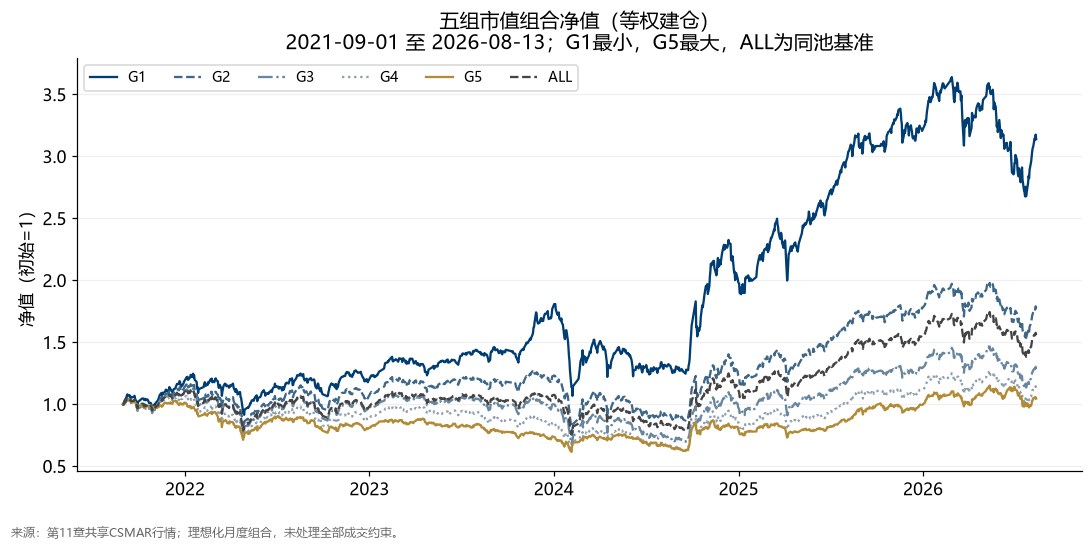

In [11]:
COLORS = {"G1": "#003D73", "G2": "#3F6788", "G3": "#68879F", "G4": "#8D9EAC", "G5": "#B18B36", "ALL": "#444444"}
STYLES = {"G1": "-", "G2": "--", "G3": "-.", "G4": ":", "G5": "-", "ALL": "--"}
PERIOD = f"{ew['gross'].index[0]:%Y-%m-%d} 至 {ew['gross'].index[-1]:%Y-%m-%d}"

def save_figure(fig, name):
    fig.text(0.01, 0.01, "来源：第11章共享CSMAR行情；理想化月度组合，未处理全部成交约束。", fontsize=8, color="#666666")
    fig.tight_layout(rect=(0, 0.045, 1, 1))
    fig.savefig(FIGURES / f"{name}.png", dpi=180)
    fig.savefig(FIGURES / f"{name}.pdf")
    plt.show()

def wealth_with_start(returns):
    wealth = (1 + returns).cumprod()
    # 在第一笔收益之前补上建仓日净值1，方便看清投资起点并正确计算绘图回撤。
    initial = pd.DataFrame(1.0, index=[schedule.execution_date.iloc[0]], columns=returns.columns)
    return pd.concat([initial, wealth])

fig, ax = plt.subplots(figsize=(10, 5))
wealth = wealth_with_start(ew["gross"])
for name in wealth.columns:
    ax.plot(wealth.index, wealth[name], label=name, color=COLORS[name], linestyle=STYLES[name], linewidth=1.5)
ax.set(title=f"五组市值组合净值（等权建仓）\n{PERIOD}；G1最小，G5最大，ALL为同池基准", ylabel="净值（初始=1）")
ax.legend(ncol=6, fontsize=9)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "group_nav")

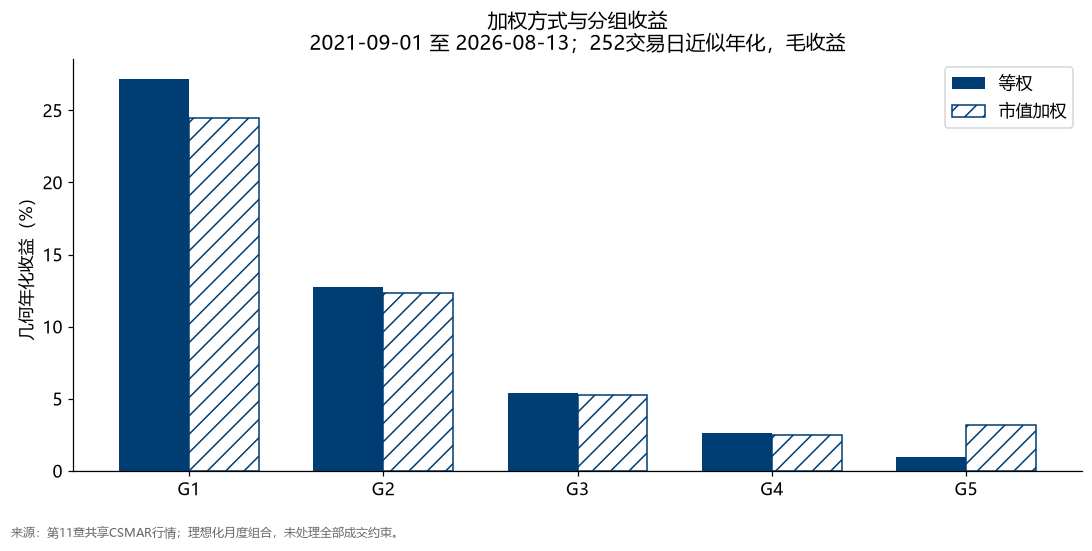

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
ew_ann = performance(ew["gross"]).loc[GROUPS, "几何年化收益"] * 100
vw_ann = performance(vw["gross"]).loc[GROUPS, "几何年化收益"] * 100
ax.bar(x - 0.18, ew_ann, width=0.36, color="#003D73", label="等权")
ax.bar(x + 0.18, vw_ann, width=0.36, facecolor="white", edgecolor="#003D73", hatch="//", label="市值加权")
ax.set(xticks=x, xticklabels=GROUPS, ylabel="几何年化收益（%）", title=f"加权方式与分组收益\n{PERIOD}；252交易日近似年化，毛收益")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.legend()
save_figure(fig, "weighting_comparison")

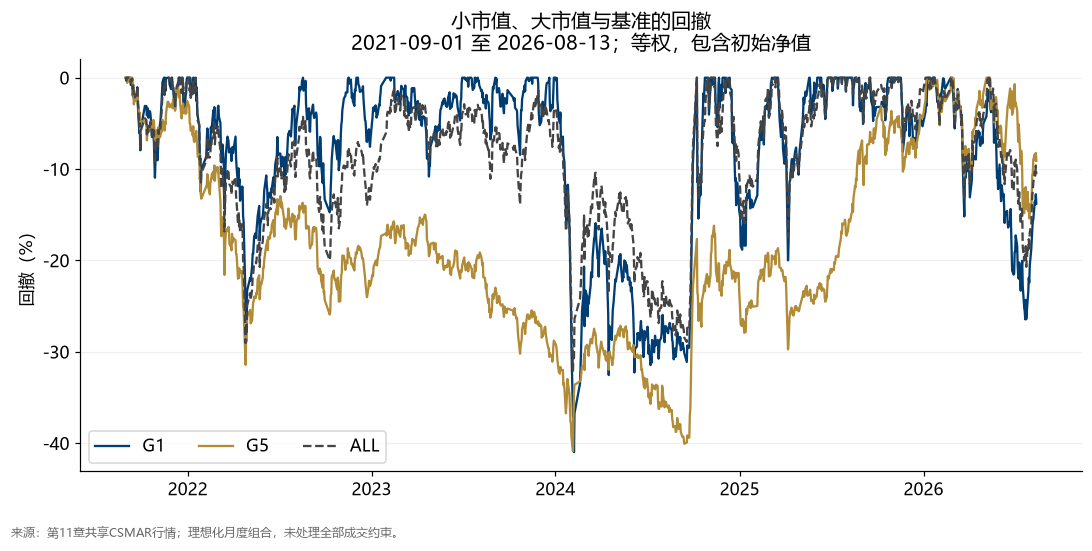

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for name in ["G1", "G5", "ALL"]:
    drawdown = wealth[name] / wealth[name].cummax() - 1
    ax.plot(drawdown.index, drawdown * 100, color=COLORS[name], linestyle=STYLES[name], label=name)
ax.set(title=f"小市值、大市值与基准的回撤\n{PERIOD}；等权，包含初始净值", ylabel="回撤（%）")
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "drawdown")

### 6.2 小减大：先作为研究差值

每月G1持有收益减G5持有收益，用于检查大小市值的相对表现。它没有定义多空资金、保证金、融券和再平衡方式，因此本章不将其连乘成“可投资多空净值”。它也不是标准FF SMB。

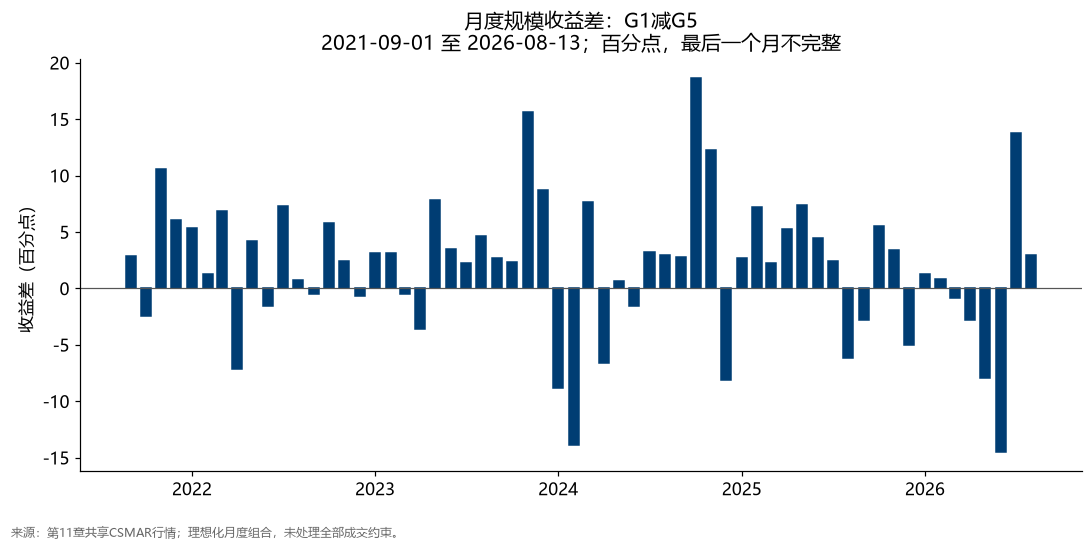

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
spread = monthly["small_minus_big"] * 100
dates = monthly.index.to_timestamp()
ax.bar(dates, spread, width=20, color="#003D73", edgecolor="#003D73")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title=f"月度规模收益差：G1减G5\n{PERIOD}；百分点，最后一个月不完整", ylabel="收益差（百分点）")
save_figure(fig, "monthly_spread")

## 7. 结果对微盘股票和交易成本有多敏感？

敏感性实验在每个信号日先删除市值最小的10%，然后重新分成五组；因此G1的成员定义已改变。
参数事先固定，不根据哪条曲线最好再选规则。成本情景使用上文定义的每边10bp，不能替代真实费用核算。

,累计收益,几何年化收益,年化波动率,最大回撤
基础G1毛收益,2.1385,0.2720,0.2949,-0.4099
剔除最小10%后G1,1.2975,0.1912,0.2853,-0.4154
基础G1成本后,2.0914,0.2680,0.2948,-0.4100
同池等权基准,0.5593,0.0980,0.2464,-0.3217


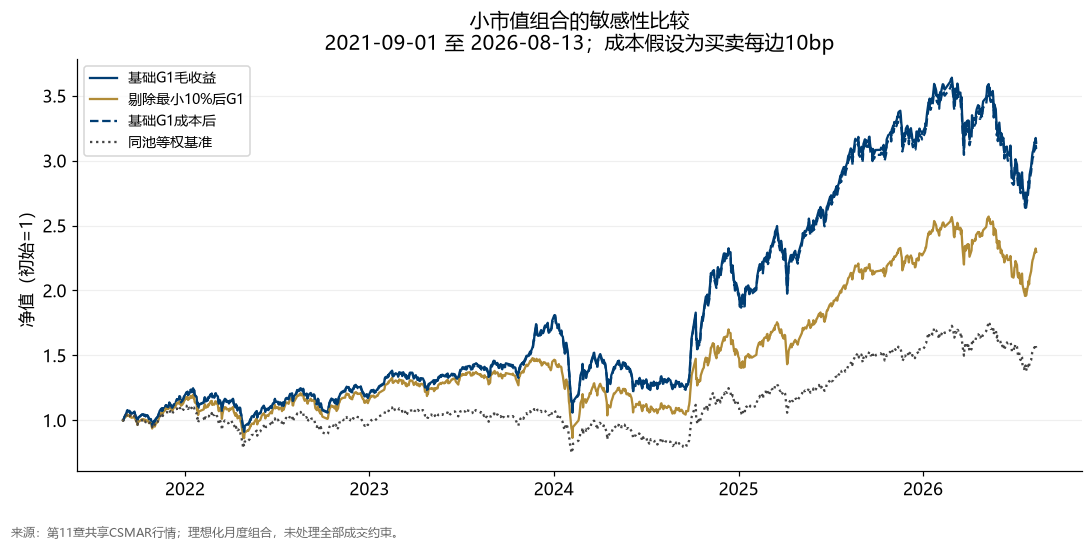

In [15]:
# 把同日期下的不同实验放在一起比较；剔除微盘后的G1与基础G1成员并不相同。
comparison = pd.DataFrame({"基础G1毛收益": ew["gross"].G1,
                           "剔除最小10%后G1": trimmed["gross"].G1,
                           "基础G1成本后": ew["net"].G1,
                           "同池等权基准": ew["gross"].ALL})
sensitivity = performance(comparison)
display(sensitivity.round(4))
fig, ax = plt.subplots(figsize=(10, 5))
for (name, series), color, style in zip(wealth_with_start(comparison).items(),
        ["#003D73", "#B18B36", "#003D73", "#444444"], ["-", "-", "--", ":"]):
    ax.plot(series.index, series, label=name, color=color, linestyle=style)
ax.set(title=f"小市值组合的敏感性比较\n{PERIOD}；成本假设为买卖每边10bp", ylabel="净值（初始=1）")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "sensitivity")

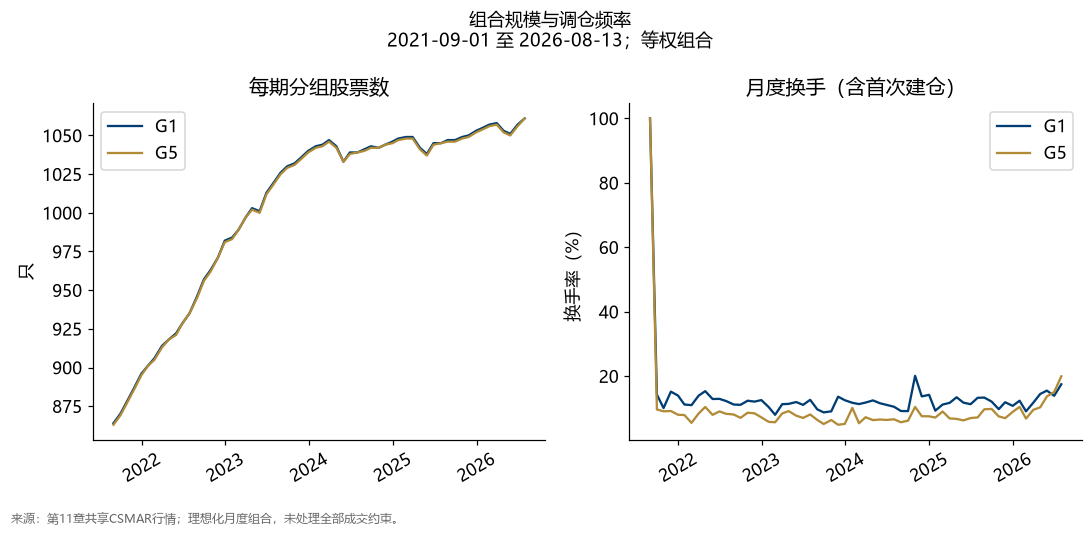

In [16]:
composition = ew["composition"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
for name in ["G1", "G5"]:
    part = composition.loc[composition.group.eq(name)]
    axes[0].plot(part.signal_date, part.stocks, color=COLORS[name], linestyle=STYLES[name], label=name)
    diag = ew["diagnostics"].loc[ew["diagnostics"].group.eq(name)]
    axes[1].plot(diag.execution_date, diag.turnover * 100, color=COLORS[name], label=name)
axes[0].set(title="每期分组股票数", ylabel="只")
axes[1].set(title="月度换手（含首次建仓）", ylabel="换手率（%）")
for ax in axes:
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"组合规模与调仓频率\n{PERIOD}；等权组合", fontsize=12)
save_figure(fig, "composition_turnover")

## 8. 核验：回测是否真的按约定运行？

除了断言时间顺序与权重合计，还独立核算首期G1：逐只股票计算整个持有期价格比值，再按初始权重求和，和逐日组合收益连乘比较。
同时查看缺失估值、无法支持成交的退出权重、涨跌停目标权重。这些指标使简化假设可见；它们不等于已经修复实盘限制。

In [17]:
selected = w0.index[w0.G1.gt(0)]
# 独立逐股计算期末/建仓价格比值，按初始投入加总并加入现金，再减1得到首期收益。
manual_first_month = sum(float(w0.loc[s, "G1"] * prices.loc[first.holding_end, s] / prices.loc[first.execution_date, s]) for s in selected) + cash0.G1 - 1
# 另一条路径对首期组合日收益连乘；两种算法一致，才支持持有期收益计算正确。
chained_first_month = first_returns.G1.add(1).prod() - 1
assert np.isclose(manual_first_month, chained_first_month, atol=1e-12)
assert np.allclose(first_end_weights.sum() + first_end_cash, 1)
assert (monthly.index[monthly.complete_month].max() < calendar[-1].to_period("M"))

# 跨月汇总各组诊断：股票日数求和；现金、缺失估值和成交局限权重取最坏一期。
diagnostic_summary = ew["diagnostics"].groupby("group").agg(
    mean_turnover=("turnover", "mean"), stale_stock_days=("stale_stock_days", "sum"),
    max_cash_weight=("cash_weight", "max"), max_stale_initial_weight=("max_stale_initial_weight", "max"),
    max_untradable_exit_weight=("untradable_exit_weight", "max"), max_limit_target_weight=("limit_target_weight", "max"))
display(diagnostic_summary.round(6))
print("首期手工聚合与逐日连乘的误差：", abs(manual_first_month - chained_first_month))

,mean_turnover,stale_stock_days,max_cash_weight,max_stale_initial_weight,max_untradable_exit_weight,max_limit_target_weight
group,,,,,,
ALL,0.061880,6591,0.007676,0.008603,0.007278,0.162157
G1,0.135441,2428,0.019175,0.023832,0.019374,0.068073
G2,0.212868,1271,0.005758,0.011976,0.008427,0.087332
G3,0.208466,1030,0.009597,0.010516,0.009923,0.142994
G4,0.164682,944,0.003839,0.006692,0.005734,0.224568
G5,0.096065,918,0.001912,0.004771,0.004940,0.287908


首期手工聚合与逐日连乘的误差： 2.220446049250313e-16


### 8.1 结果可以说明什么？

- 能描述这份数据、这段历史、这些筛选和估值约定下的组间差异。
- 全历史是教学探索样本，没有单独锁定样本外区间；多种对比不构成统计显著性或因果证据。
- 沿用旧估值会低估缺失期间风险；终止记录后的实际回收未验证，可能偏高或偏低估收益。
- 日频成交额、涨跌停状态无法证明在指定收盘价可成交。停牌退出、滑点、冲击和退市结算尚未完整模拟。
- 当前上市退市名单、代码变更、历史证券范围没有独立权威名单核对，不能宣称无幸存者偏差。
- 不能把相对收益优势直接称为alpha；后续结合适用于A股的因子和无风险利率再分析。

## 9. 导出汇总表和课件数字

只导出汇总结果，不导出原始行情副本。Notebook生成的数字供课件引用；更改参数后需重新执行并编译课件。
源文件记录路径、行数、大小及修改时间，便于检查来源；不进行哈希或SHA校验。

In [18]:
tables = {"source_year_profile": profile, "sample_flow": sample_flow, "schedule": schedule,
          "first_sort": example_summary, "performance": summary, "annual_returns": annual,
          "monthly_returns": monthly, "daily_returns_ew": ew["gross"], "daily_returns_vw": vw["gross"],
          "daily_returns_ew_net": ew["net"], "sensitivity": sensitivity,
          "composition": composition, "diagnostics_ew": ew["diagnostics"],
          "diagnostics_vw": vw["diagnostics"], "diagnostics_trimmed": trimmed["diagnostics"],
          "diagnostic_summary": diagnostic_summary}
for name, table in tables.items():
    table.to_csv(TABLES / f"{name}.csv", encoding="utf-8-sig")

facts = {"source": str(SOURCE.relative_to(ROOT)), "source_rows": source_rows,
    "source_bytes": SOURCE.stat().st_size, "source_mtime": SOURCE.stat().st_mtime,
    "source_start": str(source_start.date()), "source_end": str(source_end.date()),
    "a_share_rows": len(data), "signal_first": str(schedule.signal_date.iloc[0].date()),
    "execution_first": str(schedule.execution_date.iloc[0].date()),
    "return_start": str(ew["gross"].index[0].date()), "return_end": str(ew["gross"].index[-1].date()),
    "return_days": len(ew["gross"]), "rebalances": len(schedule),
    "complete_months": int(monthly.complete_month.sum()), "size_field": SIZE,
    "cost_per_side": COST_PER_SIDE, "price_return_max_gap": max_return_gap,
    "first_month_check_error": float(abs(manual_first_month - chained_first_month)),
    "small_annualized": float(summary.loc[("等权", "G1"), "几何年化收益"]),
    "big_annualized": float(summary.loc[("等权", "G5"), "几何年化收益"]),
    "small_max_drawdown": float(summary.loc[("等权", "G1"), "最大回撤"]),
    "small_net_annualized": float(sensitivity.loc["基础G1成本后", "几何年化收益"]),
    "trimmed_annualized": float(sensitivity.loc["剔除最小10%后G1", "几何年化收益"]),
    "small_monthly_win_rate": float(monthly.loc[monthly.complete_month, "small_minus_big"].gt(0).mean())}
(CHAPTER / "outputs/analysis_summary.json").write_text(json.dumps(facts, ensure_ascii=False, indent=2), encoding="utf-8")
macros = {"DataStart": facts["source_start"], "DataEnd": facts["source_end"],
          "ReturnStart": facts["return_start"], "ReturnEnd": facts["return_end"],
          "ReturnDays": str(facts["return_days"]), "Rebalances": str(facts["rebalances"]),
          "SmallAnn": f"{facts['small_annualized'] * 100:.2f}", "BigAnn": f"{facts['big_annualized'] * 100:.2f}",
          "SmallDD": f"{facts['small_max_drawdown'] * 100:.2f}",
          "SmallNetAnn": f"{facts['small_net_annualized'] * 100:.2f}", "TrimAnn": f"{facts['trimmed_annualized'] * 100:.2f}"}
(CHAPTER / "latex/analysis_numbers.tex").write_text("\n".join("\\newcommand{\\" + key + "}{" + value + "}" for key, value in macros.items()) + "\n", encoding="utf-8")
(CHAPTER / "latex/annual_table.tex").write_text((annual[["G1", "G5", "ALL"]] * 100).rename_axis("年份").to_latex(float_format="%.2f"), encoding="utf-8")
print(json.dumps(facts, ensure_ascii=False, indent=2))

{
  "source": "Chapter11 - 股票日频收益率分析\\data\\stock_daily.parquet",
  "source_rows": 6888585,
  "source_bytes": 565150850,
  "source_mtime": 1789023823.9400363,
  "source_start": "2021-08-16",
  "source_end": "2026-08-13",
  "a_share_rows": 6778694,
  "signal_first": "2021-08-30",
  "execution_first": "2021-08-31",
  "return_start": "2021-09-01",
  "return_end": "2026-08-13",
  "return_days": 1198,
  "rebalances": 60,
  "complete_months": 59,
  "size_field": "Dsmvtl2",
  "cost_per_side": 0.001,
  "price_return_max_gap": 5.311710643690626e-06,
  "first_month_check_error": 2.220446049250313e-16,
  "small_annualized": 0.2719939772948121,
  "big_annualized": 0.009427542173061187,
  "small_max_drawdown": -0.4098843404826874,
  "small_net_annualized": 0.2679602603908846,
  "trimmed_annualized": 0.19121131848167483,
  "small_monthly_win_rate": 0.6779661016949152
}


## 10. 课堂练习与下一章

1. 先预测等权与市值加权的差异，再用图表验证；解释预测未成立的情形。
2. 观察2024年与其他年份，G1是否始终领先？平均收益是否掩盖了某段风险？
3. 将 `SIZE` 改为 `Dsmvosd`，从头运行；解释“流通规模”和“总股本规模”的区别。
4. 将五组改成十组时，先检查代码中标签、图表与课件是否仍适用，而不是只改参数就交付。
5. 使用月末当日市值排序和本章提前一个交易日排序，分别会有哪些信息时点问题？
6. 找到 `untradable_exit_weight` 最大的月份，说明要补充什么交易机制，才能把理想化组合变成可执行策略。

下一章复用排序、权重和估值流程，将市值信号换成动量、反转或低波动。人的工作仍是提出假设、明确规则并核验结果。

参考：[Kenneth French因子构造说明](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html)。仅用于说明标准SMB与简单规模收益差的区别，本章没有使用美国因子数据。